In [1]:
# coding: utf-8
import sys, os

import numpy as np
from numba import jit
import matplotlib.pyplot as plt
sys.path.append('../../official_github/')
# from dataset.mnist import load_mnist
from simple_convnet import SimpleConvNet
# from common.trainer import Trainer


In [2]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import pickle
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient
from numba import jit




In [3]:
test_dict = {}
train_dict = {}
root_path = '../datasets/cifar-10-batches-py/'


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

accepted_keys = [b'labels', b'data'] ## select keys from [b'batch_label', b'labels', b'data', b'filenames']
for dir in os.listdir(root_path):
    if dir == 'batches.meta':
        pass
    elif dir == 'test_batch':
        test_batch = unpickle(os.path.join(root_path, dir))
        test_dict.update((k,np.array(v)) for k,v in test_batch.items() if k in accepted_keys)
    else:
        train_batch = unpickle(os.path.join(root_path, dir))
        if not train_dict:
            train_dict.update((k,np.array(v)) for k,v in train_batch.items() if k in accepted_keys)
        else:
            for key in accepted_keys:
                train_dict[key] = np.concatenate((train_dict[key], train_batch[key]), axis=0)


## CIFAR data's shape are (N, H*W*C). 
## If you want to convert them into numpy-standard (N, H, W, C) or pytorch-standard (N, C, H ,W) shape, run following codes.
def numpy2rgb(arr: np.ndarray, way='torch') -> np.ndarray:
    batch_size = len(arr)
    if way == 'numpy':
        arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,2,3,1)
    elif way == 'torch':
        arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,1,2,3)
        
    
    return arr


train_dict[b'data'] = numpy2rgb(train_dict[b'data'])
test_dict[b'data'] = numpy2rgb(test_dict[b'data'])

In [4]:
# @jit
def normalize(data: np.ndarray, mean: int=None, std: int=None) -> np.ndarray:
    if mean == None:
        mean = np.mean(data)
        
    if std == None:
        std = np.std(data)
    
    data = (data - mean) / std
    return data

In [5]:
x_train, t_train = normalize(train_dict[b'data']), train_dict[b'labels']
x_test, t_test = normalize(test_dict[b'data']), test_dict[b'labels']

print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 3, 32, 32)
2.09341038199596
(50000,)


In [6]:
network_dict = {
                'simpleConv': SimpleConvNet(input_dim=(3,32,32),
                                            conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                                            hidden_size=100, output_size=10, weight_init_std=0.01)
                }

In [7]:
network_dict['simpleConv'].params.keys()

dict_keys(['W1', 'b1', 'W2', 'b2', 'W3', 'b3'])

In [8]:
# net = network_dict['simpleConv']
# print(net.layers)
# N, C, H, W = x_train[:10].shape
# print(net.params['W1'].shape)
# out_h = (H + 2*0 - 5)//1 + 1
# out_w = (W + 2*0 - 5)//1 + 1
# print(out_h, out_w)

In [9]:
# 하이퍼 파라메터
iters_num = 50_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.01
iter_per_epoch = max(train_size / batch_size, 1)

In [10]:
# @jit
def train(key, network, output_dict):
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2', 'W3', 'b3'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    return None
            

In [11]:
# %%timeit
output_dict = {}
for key, network in network_dict.items():

    train(key, network, output_dict)
        
    print('='*10)
    print('\n\n')


=== simpleConv network training start ===
loss: 2.3029190977957876
--- simpleConv result report ---
train acc, test acc | 0.09222, 0.0927
loss: 2.302608051152562
loss: 2.3026556210554
loss: 2.3025629963069734
loss: 2.302073618103808
loss: 2.302328425861558
loss: 2.302816835329224
loss: 2.3022967435426205
loss: 2.3023404611737375
loss: 2.30269822552205
loss: 2.302638072608636
loss: 2.3024291767468794
loss: 2.3021727692072123
loss: 2.302406911201938
loss: 2.302825366369606
loss: 2.3022279880264884
loss: 2.302111943957795
loss: 2.3025795877851127
loss: 2.302232152176673
loss: 2.302346480694093
loss: 2.302730763516473
loss: 2.3021284707687015
loss: 2.302030286184885
loss: 2.302190894519552
loss: 2.302771653458768
loss: 2.3016079667478904
loss: 2.3014959879489343
loss: 2.3023113514542293
loss: 2.302478273712434
loss: 2.302890181651852
loss: 2.3023957263849377
loss: 2.3021409219358313
loss: 2.302623539427902
loss: 2.3027473004520806
loss: 2.3021323934131575
loss: 2.3024410625859435
loss: 2.3

KeyboardInterrupt: 

In [ ]:
# @jit
# def train(key, network, output_dict):
#     output_dict[f'{key} train acc'] = []
#     output_dict[f'{key} test acc'] = []
    
#     print(f'=== {key} network training start ===')
#     for i in range(iters_num):
#         print(i)
#         # 미니배치 획득
#         batch_mask = np.random.choice(train_size, batch_size)
#         x_batch = x_train[batch_mask]
#         t_batch = t_train[batch_mask]

#         # 오차역전파법으로 기울기 계산
#         grad = network.gradient(x_batch, t_batch)

#         # 매개변수 갱신
#         for param in ('W1', 'b1', 'W2', 'b2', 'W3', 'b3'):
#             network.params[param] -= learning_rate * grad[param]

#         # 학습 경과 기록
#         loss = network.loss(x_batch, t_batch)
#         print('loss:', loss)

#         # 1에폭 당 정확도 계산
#         if i % iter_per_epoch == 0:
#             train_acc = network.accuracy(x_train, t_train)
#             test_acc = network.accuracy(x_test, t_test)
#             output_dict[f'{key} train acc'].append(train_acc)
#             output_dict[f'{key} test acc'].append(test_acc)
#             print(f'--- {key} result report ---')
#             print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
#         return None

C:\Users\dieyo\AppData\Local\Temp\ipykernel_14756\245783409.py:1: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit


In [ ]:
# %%timeit
# jit_output_dict = {}
# for key, network in network_dict.items():

#     train(key, network, jit_output_dict)
        
#     print('='*10)
#     print('\n\n')


C:\Users\dieyo\AppData\Local\Temp\ipykernel_14756\245783409.py:1: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "train" failed type inference due to: non-precise type pyobject
During: typing of argument at C:\Users\dieyo\AppData\Local\Temp\ipykernel_14756\245783409.py (1)

File "..\..\..\..\..\AppData\Local\Temp\ipykernel_14756\245783409.py", line 1:
<source missing, REPL/exec in use?>

  @jit
c:\Users\dieyo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numba\core\object_mode_passes.py:151: NumbaWarning: Function "train" was compiled in object mode without forceobj=True.

File "..\..\..\..\..\AppData\Local\Temp\ipykernel_14756\245783409.py", line 1:
<source missing, REPL/exec in use?>

  warnings.warn(errors.NumbaWarning(warn_msg,
c:\Users\dieyo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numba\core\object_mode_passes.py:161: NumbaDeprecationWarning: 
Fall-back from the nopython compilation path to the obje

=== simpleConv network training start ===
0
loss: 2.3015261802218876
--- simpleConv result report ---
train acc, test acc | 0.1344, 0.1382



=== simpleConv network training start ===
0
loss: 2.3022528035398717
--- simpleConv result report ---
train acc, test acc | 0.137, 0.1403



=== simpleConv network training start ===
0
loss: 2.301976529649669
--- simpleConv result report ---
train acc, test acc | 0.13778, 0.14



=== simpleConv network training start ===
0
loss: 2.301357715368427
--- simpleConv result report ---
train acc, test acc | 0.13782, 0.1401



=== simpleConv network training start ===
0
loss: 2.3020847360299115
--- simpleConv result report ---
train acc, test acc | 0.13562, 0.1393



=== simpleConv network training start ===
0
loss: 2.301948357767586
--- simpleConv result report ---
train acc, test acc | 0.13596, 0.1401



=== simpleConv network training start ===
0
loss: 2.302068144568218
--- simpleConv result report ---
train acc, test acc | 0.14088, 0.1457



=== simp

### 그래프는 나중에

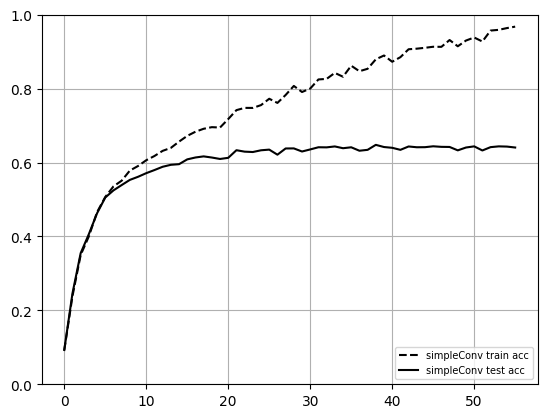

In [12]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'
    else:
        color_code = 'k'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right', prop={'size':7})
plt.grid()